In [1]:
import warnings

import control as ct
import control.matlab as ct_matlab
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import solve_discrete_are

import params
from matrix_utils import generate_prbs, make_smm
from plotting import plot_gust_inputs, plot_gust_response
from smm_predictors import make_Lp_S_Lf, make_SMM_pred,make_XZ
from system_models import flight_model, make_ss_smm_pred

In [2]:
# Initialize system and parameters
plt.rcParams.update(params.PLOT_STYLE)
np.random.seed(111)

In [3]:
Gs = flight_model(params.GUST_SIGMA)

In [4]:
# 2) Simulate gusts and plant response
uw_zero = np.zeros((params.K_GUST, params.NU))
ww_noise = np.random.default_rng(111).standard_normal((params.K_GUST, params.NW))

# Stack inputs [u , w]
inputs = np.hstack((uw_zero, ww_noise))

(4, 5000)


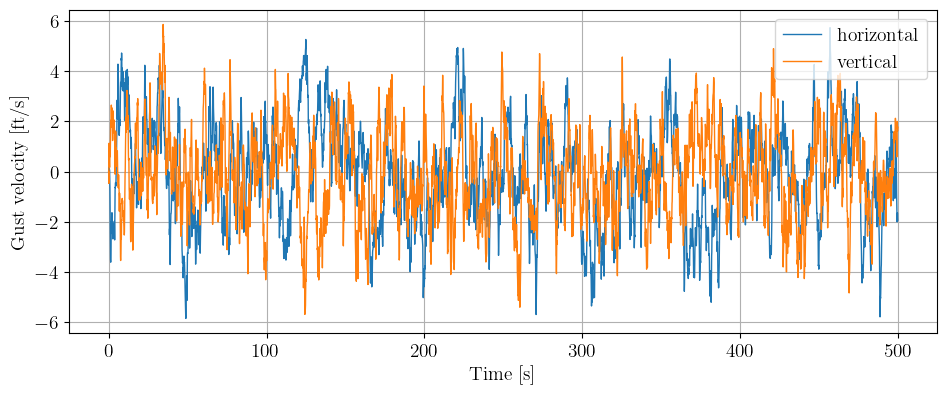

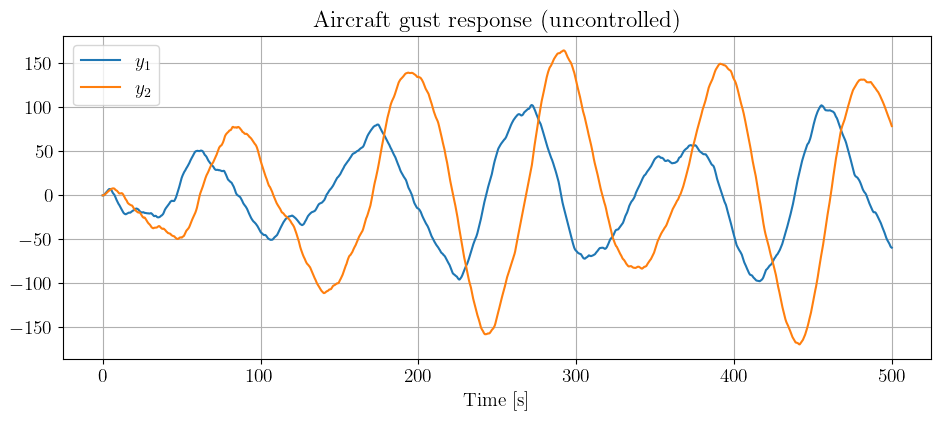

In [5]:
# Extract and plot gust velocities
U = inputs.T
# Now request states as well
t_sim, y_out, x_states = ct.forced_response(
    Gs,
    T=params.TSIM_GUST,
    U=U,
    return_x=True
)

# y_out has shape (n_outputs, n_steps)
print(y_out.shape)   # e.g. (4, 5000)

# Extract horizontal & vertical gusts (outputs 3 & 4)
wgusts = y_out[2:4, :]       # shape (2, 5000)
wgusts_t = wgusts.T          # shape (5000, 2) for plotting

plt.figure(figsize=params.FIG_SIZE)
plt.plot(t_sim, wgusts_t[:,0], label='horizontal', linewidth=1)
plt.plot(t_sim, wgusts_t[:,1], label='vertical',   linewidth=1)
plt.xlabel('Time [s]')
plt.ylabel('Gust velocity [ft/s]')
plt.legend()
plt.grid(True)
plt.show()

# Extract the two outputs, then transpose to (time, channels)
aircraft_resp = y_out[0:2, :].T  # shape → (5000, 2)

plt.figure(figsize=params.FIG_SIZE)
plt.plot(params.TSIM_GUST, aircraft_resp[:, 0], label=r'$y_1$', linewidth=1.5)
plt.plot(params.TSIM_GUST, aircraft_resp[:, 1], label=r'$y_2$', linewidth=1.5)

plt.grid(True)
plt.legend()
plt.title('Aircraft gust response (uncontrolled)')
plt.xlabel('Time [s]')
plt.show()

In [6]:
# 1) Discretize via zero-order hold
Ts     = params.TS                    # 0.1
Gfullz = ct.c2d(Gs, Ts, 'zoh')           # discrete‐time SS model

# 2) Extract plant vs. gust outputs
Gz    = Gfullz[0:2, :]                # velocity & climb‐rate subsystem
Gustz = Gfullz[2:4, :]                # gust‐velocity subsystem
# 3) Print true plant order
Gnx = Gz.A.shape[0]
print(f"True plant order = {Gnx}")

True plant order = 7


In [12]:

rng       = np.random.default_rng(111)
PRBS_LEN  = params.K_DATA + params.TF           # 2500 + 20
PRBS_SIGS = params.NU + params.NW               # 2 + 2 = 4 channels
PRBS_SCALE= params.PRBS_SCALE                   # 3.0
uwmod     = PRBS_SCALE * rng.choice(             # shape (2520,4)
    [-1, 1], size=(PRBS_LEN, PRBS_SIGS)
)
tsim_id   = params.TSIM_MODEL                    # length 2520

# 2) Full-system nominal response (u+w)
U_full    = uwmod.T                              # (4,2520)
t_prbs, y_nom = ct.forced_response(
    Gz, T=tsim_id, U=U_full
)  # y_nom.shape == (2,2520)

# Slice out first 2500 steps for identification
umod = uwmod[:params.K_DATA, :params.NU]         # (2500,2)
wmod = uwmod[:params.K_DATA, params.NU:]         # (2500,2)

# 3) Nominal response with w=0 (only u)
Gz_u      = Gz[:, :params.NU]                    # 2-out,2-in subsystem
U_u       = uwmod[:, :params.NU].T               # (2,2520)
t_prbs_u, y_nom_u = ct.forced_response(
    Gz_u, T=tsim_id, U=U_u
)  # y_nom_u.shape == (2,2520)

# 4) Reference signal and design specs (from params)
t_ref_clp = params.T_REF_CLP                     # sim_len+Tf
y_ref     = params.Y_REF                         # shape (len(t_ref_clp),2)
Q_perf    = params.Q_PERF
R_perf    = params.R_PERF
ULB, UUB  = params.ULB, params.UUB
YLB, YUB  = params.YLB, params.YUB

In [13]:

# Monte Carlo simulation configuration
n_mc = params.N_MC
print(f"\nMonte Carlo simulation: {n_mc} runs")

# Assumes `rng = np.random.default_rng(111)` was defined earlier for reproducibility

# Preassign noise arrays
vmod_mc = rng.standard_normal((params.K_DATA + params.TF, params.NY, n_mc))
vsim_mc = rng.standard_normal((params.SIM_LEN_CLP, params.NY, n_mc))
wsim_mc = rng.standard_normal((params.SIM_LEN_CLP, params.NW, n_mc))

# Scale by output noise standard deviation
for idx in range(n_mc):
    vmod_mc[:, :, idx] = vmod_mc[:, :, idx] @ params.STD_DEV_V
    vsim_mc[:, :, idx] = vsim_mc[:, :, idx] @ params.STD_DEV_V

# Generate initial random input for closed-loop initialization (k <= K_INIT)
u_init = rng.standard_normal((params.NU, params.K_INIT))

# Optional: Verify dimensions
print(f'\nNoise matrix dimensions:')
print(f'vmod_mc: {vmod_mc.shape} (time x outputs x trials)')
print(f'vsim_mc: {vsim_mc.shape} (time x outputs x trials)')
print(f'wsim_mc: {wsim_mc.shape} (time x disturbances x trials)')
print(f'u_init:  {u_init.shape}  (inputs x initialization steps)')


Monte Carlo simulation: 30 runs

Noise matrix dimensions:
vmod_mc: (2520, 2, 30) (time x outputs x trials)
vsim_mc: (301, 2, 30) (time x outputs x trials)
wsim_mc: (301, 2, 30) (time x disturbances x trials)
u_init:  (2, 30)  (inputs x initialization steps)


# Main SMM MPC

In [14]:
import scipy.sparse as sp

# Signal matrix model predictive control (SMMPC)
print("\nSignal matrix model predictive control")
print(f"  T = {params.T}, Tp = {params.TP}, Tf = {params.TF}, M = {params.M}")

# Storage arrays for Monte Carlo results
uMC_SMMK = np.zeros((params.NU, params.SIM_LEN_CLP, params.N_MC))   # MPC inputs
yMC_SMMK = np.zeros((params.NY, params.SIM_LEN_CLP, params.N_MC))   # plant outputs

ISE_SMMK = np.zeros(params.N_MC)   # integral squared error
IAE_SMMK = np.zeros(params.N_MC)   # integral absolute error
IE_SMMK  = np.zeros(params.N_MC)   # input energy

# Precompute parts of the OSQP cost
RperfTf = sp.kron(sp.eye(params.TF), params.R_PERF, format='csc')
QperfTf = sp.kron(sp.eye(params.TF), params.Q_PERF, format='csc')

# Correct block‐diag call:
Pcost = 2 * sp.block_diag([RperfTf, QperfTf], format='csc')

# Reference over the next Tf steps (vectorized)
# params.Y_REF: shape (sim_len+Tf, NY)
yref_mat = params.Y_REF.T               # now (NY, sim_len+Tf)
yrefTf   = yref_mat[:, :params.TF]      # first Tf columns → (NY, Tf)
yrefTf   = yrefTf.reshape(params.NY * params.TF, order='F')


Signal matrix model predictive control
  T = 50, Tp = 30, Tf = 20, M = 2451


In [15]:
# Pre-extract for convenience
sim_len = params.SIM_LEN_CLP
K_DATA  = params.K_DATA
TF      = params.TF
TP      = params.TP
NY      = params.NY
NU      = params.NU
NW      = params.NW
nMC     = params.N_MC
M       = params.M
TS      = params.TS

In [16]:
import osqp
import scipy.sparse as sp

In [20]:
for mc_idx in range(nMC):
    # System variables
    xsys  = np.zeros((Gnx, sim_len+1))                # true system state
    usys  = np.zeros((NU, sim_len+1))                 # input to system
    # process noise & measurement noise for this run
    wsys  = wsim_mc[:sim_len, :, mc_idx].T          # shape → (NW, sim_len)
    vsys  = vsim_mc[:sim_len, :, mc_idx].T          # shape → (NY, sim_len)
    ysys  = np.zeros((NY, sim_len+1))                 # true noise‐free output
    ymeas = np.zeros((NY, sim_len+1))                 # noisy output
    gvsys = np.zeros((NW, sim_len+1))                 # gust velocities

    # model noise for identification (drop first sample)
    # vmod_mc shape is (K_DATA+TF, NY, n_mc)
    ymodnoise = vmod_mc[1 : K_DATA+1, :, mc_idx]    # shape → (K_DATA, NY)

    # measurement noise over full sim
    ysimnoise = vsim_mc[:, :, mc_idx]               # shape → (sim_len, NY)

    y_nom_shifted = y_nom[:, 1 : K_DATA + 1].T        # shape → (K_data, NY)
    ymod = y_nom_shifted + ymodnoise                  # add model noise

    # 5) Calculate the SMM Hankel matrices

    Hup, Huf = make_smm(umod, TP, TF, M)
    Hwp, Hwf = make_smm(wmod, TP, TF, M)
    Hyp, Hyf = make_smm(ymod, TP, TF, M)

    # 6) Stack past‐ and future‐horizon I/O
    Huwyp = np.vstack([Hup, Hwp, Hyp])
    Huwyf = np.vstack([Huf, Hwf, Hyf])

    # 7) Determine reduced‐model dimension
    nxy = NY * (TP - 1)

    # 8) Decompose to parameterize the subspaces
    Lp, S, Lf, Lyyf = make_Lp_S_Lf(Huwyp, Huwyf, NU, NW, NY, nxy)

    # 9) Check that Lyyf is (near) zero in the noise‐free case
    print(f"Lyyf test (zero in noise‐free case), norm(Lyyf) = {np.linalg.norm(Lyyf):g}")

    # --- Recursive (xu; xw; xy) predictor ---
    ss_preduwy = make_ss_smm_pred(Lp, NU, NW, NY, TP, TS)

    # MATLAB 1-based → Python 0-based indices
    up_idx    = np.arange(0,      NU*TP)                      # 1:nu*Tp
    y_idx     = np.arange(NU+NW,  NU+NW+NY)                   # (nu+nw+1):(nu+nw+ny)
    xwyp_idx  = np.arange(NU*TP,  (NU+NW)*TP + nxy)           # (nu*Tp+1):((nu+nw)*Tp+nxy)
    yd_idx    = np.arange((NU+NW)*TF, (NU+NW+NY)*TF)          # (nu+nw)*Tf+1 : (nu+nw+ny)*Tf

    # Extract sub-blocks from the predictor SS matrices
    Ar      = ss_preduwy.A[np.ix_(xwyp_idx, xwyp_idx)]
    Cr      = ss_preduwy.C[np.ix_(y_idx,    xwyp_idx)]
    Bur     = ss_preduwy.B[np.ix_(xwyp_idx, np.arange(0, NU))]
    Bwr     = ss_preduwy.B[np.ix_(xwyp_idx, np.arange(NU, NU+NW))]

    ne      = len(xwyp_idx)         # estimated state dim
    nye     = TF * NY               # output-penalty dim

    Auu         = ss_preduwy.A[np.ix_(up_idx, up_idx)]
    Axwy_xu     = ss_preduwy.A[np.ix_(xwyp_idx, up_idx)]
    Buu         = ss_preduwy.B[np.ix_(up_idx, np.arange(0, NU))]
    Cyu         = ss_preduwy.C[np.ix_(y_idx,   up_idx)]

    Sywy    = S[np.ix_(yd_idx, xwyp_idx)]

        # 10) Block‐matrix calculation for the predictor

    # Indices for future‐horizon blocks (MATLAB 1-based → Python 0-based)
    uwf_idx = np.arange(0, (NU + NW) * TF)             # 1:(nu+nw)*Tf
    yf_idx  = np.arange((NU + NW) * TF, (NU + NW + NY) * TF)  # (nu+nw)*Tf+1 : (nu+nw+ny)*Tf

    # Partition S and Lf
    Suwx   = S[uwf_idx, :]                              # shape → ( (nu+nw)*Tf, ... )
    Syx    = S[yf_idx, :]

    Lfout  = Lf[yf_idx, :]
    Lfin   = Lf[uwf_idx, :]

    # Compute SFpred = [Syx, 0] - Lfout/Lfin * [Suwx, -I]
    # MATLAB's Lfout / Lfin  is Lfout * inv(Lfin)
    top_block = np.hstack([Syx, np.zeros((NY * TF, (NU + NW) * TF))])
    bottom_block = np.hstack([Suwx, -np.eye((NU + NW) * TF)])
    LFinv = np.linalg.pinv(Lfin)          # pseudo‐inverse of Lfin
    SFpred = top_block - Lfout @ LFinv @ bottom_block

    # Extract Fx, Fuf, Fwf
    split1 = (NU + NW) * TP + nxy
    split2 = split1 + NU * TF

    Fxuwy = SFpred[:, :split1]
    Fuf   = SFpred[:, split1:split2]
    Fwf   = SFpred[:, split2:split2 + (NU + NW) * TF]

    # 11) Discrete Riccati equation solution for Kalman filter
    print("\nDiscrete Riccati equation solution for Kalman filter.")

    # Process & measurement noise covariances:
    Qw = Bwr @ params.SIGMA_W @ Bwr.T    # process‐noise covariance in state eq.
    Rv = params.SIGMA_V                  # measurement‐noise covariance

    # Solve the discrete–time Riccati equation for P
    # solve_discrete_are solves: A.T P A - A.T P C.T (C P C.T + R)^{-1} C P A + Q = P
    P = solve_discrete_are(Ar.T, Cr.T, Qw, Rv)

    # Compute steady‐state Kalman gain: K = P C.T (C P C.T + R)^{-1}
    Kkf = P @ Cr.T @ np.linalg.inv(Cr @ P @ Cr.T + Rv)

    # 12) Initialize state estimates
    xhu   = np.zeros((NU * TP,    sim_len+1))         # estimate of xu(k)
    xhwy  = np.zeros((NW * TP + nxy, sim_len+1))      # estimate of [xw; xy](k)

    # 13) Reference vector over future horizon (already defined outside loop, 
    # but re‐vectorize here if needed)
    # yref is shape (sim_len+TF, NY)
    yrefTf = params.Y_REF.T[:, :TF]                # (NY, TF)
    yrefTf = yrefTf.reshape((NY * TF,), order='F')  # vectorized

    # 14) Initialize OSQP
    prob = osqp.OSQP()

    # 15) Build linear cost q = [0_u; qy] where qy = -2 * QperfTf @ yrefTf
    qy   = -2 * (QperfTf @ yrefTf)                  # shape → (NY*TF,)
    qlin = np.hstack([np.zeros(NU * TF), qy])       # shape → (NU*TF + NY*TF,)

    # 16) Build constraints for OSQP

    # Equality constraint: Aeq * z = 0, where z = [zf; yf_slack]
    # Aeq = [–Fuf,  I_{ny*Tf}]
    Aeq = sp.hstack([
        -sp.csc_matrix(Fuf),
        sp.eye(NY * TF, format='csc')
    ], format='csc')

    # Inequality: bounds on u and y ⇒ z ∈ [lIneq, uIneq]
    # Aineq = I_{ (nu+ny)*Tf }
    Aineq = sp.eye((NU + NY) * TF, format='csc')

    # Stack to get full constraint matrix
    Acons = sp.vstack([Aeq, Aineq], format='csc')

    # 17) Build inequality bounds
    # lIneq = [ 1_Tf ⊗ ulb ;  1_Tf ⊗ ylb ]
    lIneq = np.hstack([
        np.tile(ULB, TF),    # shape → (nu*Tf,)
        np.tile(YLB, TF)     # shape → (ny*Tf,)
    ])
    uIneq = np.hstack([
        np.tile(UUB, TF),
        np.tile(YUB, TF)
    ])

    # 18) Build equality bounds from current state estimate
    # state vector at k=0 → [xhu[:,0]; xhwy[:,0]]
    z0 = np.concatenate([xhu[:, 0], xhwy[:, 0]])  # shape → ( (nu+nw)*Tp + nxy, )

    # lEq = uEq = Fxuwy @ z0
    lEq = Fxuwy @ z0
    uEq = lEq.copy()

    # 19) Combined lower and upper bound vectors
    lcons = np.hstack([lEq, lIneq])
    ucons = np.hstack([uEq, uIneq])

    # 20) Setup OSQP problem
    prob.setup(P=Pcost, q=qlin, A=Acons, l=lcons, u=ucons, verbose=False)

    for k in range(sim_len):
        # 21) Compute true outputs and noisy measurement
        #    xsys[:, k] is the true state at time k
        ysys[:, k]  = Gz.C @ xsys[:, k]        # noise‐free plant output
        gvsys[:, k] = Gustz.C @ xsys[:, k]     # true gust velocities
        ymeas[:, k] = ysys[:, k] + vsys[:, k]  # add measurement noise

        # 22) Kalman filter measurement update for xhwy
        #    xu estimate remains exact since u is known
        #    xhwy(:,k) = (I - Kkf*Cr) * xhwy(:,k) - Kkf*Cyu*xhu(:,k) + Kkf*ymeas(:,k)
        xhwy[:, k] = (
            (np.eye(NW * TP + nxy) - Kkf @ Cr) @ xhwy[:, k]
            - (Kkf @ Cyu) @ xhu[:, k]
            + (Kkf @ ymeas[:, k])
        )

                # 23) Compute control input via SMMPC
        if k >= params.K_INIT:  # k >= Kinit (0‐based)
            # a) Update reference vector over future horizon
            #    Y_REF has shape (sim_len+TF, NY)
            yref_block = params.Y_REF[k : k + TF, :].T  # (NY, TF)
            yrefTf = yref_block.reshape((NY * TF,), order='F')

            # b) Rebuild dynamics bounds
            z0 = np.concatenate([xhu[:, k], xhwy[:, k]])
            lEq = Fxuwy @ z0
            uEq = lEq.copy()

            # c) Combine with static inequality bounds
            lcons = np.hstack([lEq, lIneq])
            ucons = np.hstack([uEq, uIneq])

            # d) Update linear cost term
            qy   = -2 * (QperfTf @ yrefTf)
            qlin = np.hstack([np.zeros(NU * TF), qy])

            # e) Update and solve OSQP
            prob.update(l=lcons, u=ucons, q=qlin)
            res = prob.solve()
            if res.info.status != 'solved':
                warnings.warn("OSQP did not solve the problem!")
                break
            uopt = res.x[: NU * TF]

            # f) Apply first control move
            usys[:, k] = uopt[: NU]
        else:
            # initial random excitation
            usys[:, k] = u_init[:, k]
        
        # 24) Time‐update of Kalman filter state estimates
        # Note: ensure xhu and xhwy were preallocated with shape (…, sim_len+1)
        xhu[:, k+1]  = Auu @ xhu[:, k] + Buu @ usys[:, k]
        xhwy[:, k+1] = Axwy_xu @ xhu[:, k] + Ar @ xhwy[:, k] + Bur @ usys[:, k]

        # 25) True plant propagation
        # Gz.A is shape (NY, NY) or (state_dim, state_dim)?  
        # Actually Gz has state dimension Gnx and inputs = NU+NW
        xsys[:, k+1] = Gz.A @ xsys[:, k] + Gz.B @ np.concatenate([usys[:, k], wsys[:, k]])

        # --- Save trajectories for this Monte Carlo run ---
    uMC_SMMK[:, :sim_len, mc_idx] = usys[:, :sim_len]
    yMC_SMMK[:, :sim_len, mc_idx] = ysys[:, :sim_len]

    # --- Compute performance criteria ---
    # Error from K_INIT onward (0-based)
    yerr = yMC_SMMK[:, params.K_INIT:sim_len, mc_idx] \
         - params.Y_REF[params.K_INIT:sim_len, :].T
    # Integral squared error
    ISE_SMMK[mc_idx] = np.sum(yerr**2)
    # Integral absolute error
    IAE_SMMK[mc_idx] = np.sum(np.abs(yerr))
    # Input energy from K_INIT onward
    uclp = uMC_SMMK[:, params.K_INIT:sim_len, mc_idx]
    IE_SMMK[mc_idx] = np.sum(uclp**2)

    # --- Print summary for this run ---
    t_end = params.T_CLP_GRID[sim_len-1]  # time at last step
    print(f"\nSMMPC run {mc_idx+1}/{n_mc}: simulation ended at t = {t_end} [sec] "
          f"({sim_len} time steps)")
    print(f"ISE = {ISE_SMMK[mc_idx]:g}")
    print(f"IAE = {IAE_SMMK[mc_idx]:g}")
    print(f"Input energy = {IE_SMMK[mc_idx]:g}")

Lyyf test (zero in noise‐free case), norm(Lyyf) = 0

Discrete Riccati equation solution for Kalman filter.

SMMPC run 1/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 1089.82
IAE = 524.548
Input energy = 3104.39
Lyyf test (zero in noise‐free case), norm(Lyyf) = 0

Discrete Riccati equation solution for Kalman filter.


/var/folders/1_/c6s9hxrn4k1bzxk6_n8vj2s00000gn/T/ipykernel_8381/1212837898.py:207: UserWarning: OSQP did not solve the problem!
  warnings.warn("OSQP did not solve the problem!")



SMMPC run 2/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 26656.2
IAE = 2728.04
Input energy = 2443.32
Lyyf test (zero in noise‐free case), norm(Lyyf) = 0

Discrete Riccati equation solution for Kalman filter.

SMMPC run 3/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 29276.2
IAE = 2790.37
Input energy = 5599.85
Lyyf test (zero in noise‐free case), norm(Lyyf) = 0

Discrete Riccati equation solution for Kalman filter.

SMMPC run 4/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 23435.1
IAE = 2458.3
Input energy = 2334.22
Lyyf test (zero in noise‐free case), norm(Lyyf) = 0

Discrete Riccati equation solution for Kalman filter.

SMMPC run 5/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 26771.9
IAE = 2715.66
Input energy = 3675.88
Lyyf test (zero in noise‐free case), norm(Lyyf) = 0

Discrete Riccati equation solution for Kalman filter.

SMMPC run 6/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 28537.9
IAE = 2844

In [21]:
from scipy.io import loadmat

mat_data = loadmat('matlab_smm_outputs.mat')

def compare_metric(name, py_val):
    mat_val = mat_data[name]
    diff = np.max(np.abs(mat_val - py_val))
    print(f"{name}: max diff = {diff:.2e}, match = {diff < 1e-6}")

compare_metric("uMC_SMMK", uMC_SMMK)
compare_metric("yMC_SMMK", yMC_SMMK)
compare_metric("ISE_SMMK", ISE_SMMK)
compare_metric("IAE_SMMK", IAE_SMMK)
compare_metric("IE_SMMK", IE_SMMK)

uMC_SMMK: max diff = 4.00e+01, match = False
yMC_SMMK: max diff = 3.75e+01, match = False
ISE_SMMK: max diff = 5.39e+04, match = False
IAE_SMMK: max diff = 3.25e+03, match = False
IE_SMMK: max diff = 4.03e+04, match = False


In [26]:
import h5py
import numpy as np

def load_direct_variables(filename, keys):
    """Load only specific datasets from a MATLAB v7.3 file (ignores objects)."""
    out = {}
    with h5py.File(filename, 'r') as f:
        for key in keys:
            if key not in f:
                raise KeyError(f"{key} not found in file.")
            raw = f[key][()]
            if isinstance(raw, np.ndarray) and raw.dtype.kind == 'O':
                raise ValueError(f"{key} is an object array; not supported.")
            out[key] = raw
    return out

def fix_array(name, arr):
    if name == "uInit":
        return arr.T
    elif name in {"vmodMC", "vsimMC", "wsimMC"}:
        return np.transpose(arr, (2, 1, 0))
    return arr

# --- Specify file and variables you need ---
file = "mc_debug_data.mat"
vars_to_load = ["uInit", "vmodMC", "vsimMC", "wsimMC"]

# --- Load and reshape ---
raw_data = load_direct_variables(file, vars_to_load)
data = {key: fix_array(key, arr) for key, arr in raw_data.items()}

# --- Check ---
for key, val in data.items():
    print(f"{key}: shape = {val.shape}")

# Assume you also have python-generated versions:
# vmod_mc_py, vsim_mc_py, wsim_mc_py, u_init_py

def compare_arrays(name, arr_loaded, arr_python):
    same_shape = arr_loaded.shape == arr_python.shape
    if not same_shape:
        print(f"{name}: shape mismatch! loaded={arr_loaded.shape}, python={arr_python.shape}")
        return
    max_diff = np.max(np.abs(arr_loaded - arr_python))
    print(f"{name}: max diff = {max_diff:.3e}, match = {max_diff < 1e-6}")

# Example comparison
compare_arrays("uInit", data["uInit"], u_init)
compare_arrays("vmodMC", data["vmodMC"], vmod_mc)
compare_arrays("vsimMC", data["vsimMC"], vsim_mc)
compare_arrays("wsimMC", data["wsimMC"], wsim_mc)

uInit: shape = (2, 30)
vmodMC: shape = (2520, 2, 30)
vsimMC: shape = (301, 2, 30)
wsimMC: shape = (301, 2, 30)
uInit: max diff = 3.901e+00, match = False
vmodMC: max diff = 1.884e+00, match = False
vsimMC: max diff = 1.426e+00, match = False
wsimMC: max diff = 5.731e+00, match = False


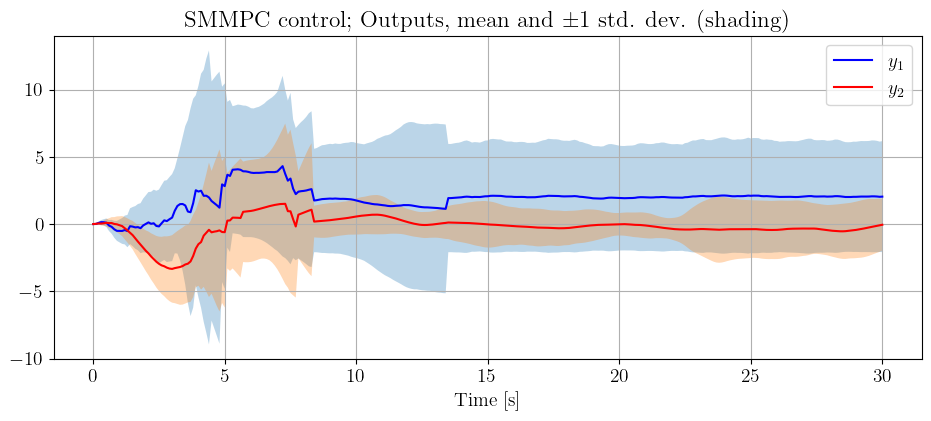

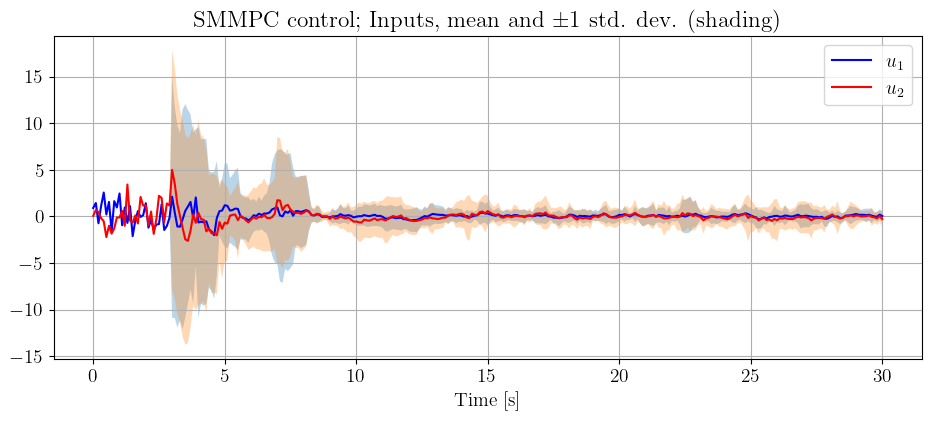

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import params

def plt_resp(t, data_mc, labels, styles):
    """
    Plot mean ±1 std shading for Monte Carlo results.
    """
    n_signals, sim_len, n_mc = data_mc.shape
    mean_vals = np.mean(data_mc, axis=2)
    std_vals  = np.std(data_mc,  axis=2)

    plt.figure(figsize=params.FIG_SIZE)
    for i in range(n_signals):
        plt.plot(t, mean_vals[i], styles[i], label=labels[i])
        plt.fill_between(
            t,
            mean_vals[i] - std_vals[i],
            mean_vals[i] + std_vals[i],
            alpha=0.3
        )
    plt.grid(True)
    plt.xlabel('Time [s]')
    plt.legend()

# Plot outputs
plt_resp(
    params.T_CLP_GRID,
    yMC_SMMK,
    labels=[r'$y_1$', r'$y_2$'],
    styles=['b-', 'r-']
)
plt.title('SMMPC control; Outputs, mean and ±1 std. dev. (shading)')

# Plot inputs
plt_resp(
    params.T_CLP_GRID,
    uMC_SMMK,
    labels=[r'$u_1$', r'$u_2$'],
    styles=['b-', 'r-']
)
plt.title('SMMPC control; Inputs, mean and ±1 std. dev. (shading)')

plt.show()

In [15]:
# --- Signal Matrix Model Predictive Control (w = 0) ---

print("\nSignal matrix model predictive control (w = 0)")

# Preallocate Monte Carlo result arrays
uMC_SMMPC = np.zeros((params.NU, params.SIM_LEN_CLP, params.N_MC))
yMC_SMMPC = np.zeros((params.NY, params.SIM_LEN_CLP, params.N_MC))

ISE_SMMPC = np.zeros(params.N_MC)
IAE_SMMPC = np.zeros(params.N_MC)
IE_SMMPC  = np.zeros(params.N_MC)

# Inequality bounds (identical each step)
lIneq = np.hstack([
    np.tile(params.ULB, params.TF),   # control bounds
    np.tile(params.YLB, params.TF)    # output bounds
])
uIneq = np.hstack([
    np.tile(params.UUB, params.TF),
    np.tile(params.YUB, params.TF)
])

# 1) Quadratic cost for w=0 case
Puf   = sp.kron(sp.eye(params.TF, format='csc'), params.R_PERF, format='csc')
Pyf   = sp.kron(sp.eye(params.TF, format='csc'), params.Q_PERF, format='csc')
Pcost = 2 * sp.block_diag([Puf, Pyf], format='csc')

# 2) Initial reference over future horizon (vectorized)
# params.Y_REF has shape (sim_len+TF, NY)
yref_mat = params.Y_REF.T           # (NY, sim_len+TF)
yrefTf  = yref_mat[:, :params.TF]   # (NY, TF)
yrefTf  = yrefTf.reshape((params.NY * params.TF,), order='F')


Signal matrix model predictive control (w = 0)


/var/folders/1_/c6s9hxrn4k1bzxk6_n8vj2s00000gn/T/ipykernel_1726/2669716576.py:108: UserWarning: OSQP did not solve the problem!
  warnings.warn("OSQP did not solve the problem!")



SMMPC run 1/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 28642.9
IAE = 3405.18
Input energy = 0

SMMPC run 2/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 32463
IAE = 3520.69
Input energy = 0

SMMPC run 3/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 98890.5
IAE = 5117.26
Input energy = 0

SMMPC run 4/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 24923.3
IAE = 2608.71
Input energy = 0

SMMPC run 5/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 19094
IAE = 2323.73
Input energy = 0

SMMPC run 6/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 25893.9
IAE = 3069.93
Input energy = 0

SMMPC run 7/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 72515.5
IAE = 5087.07
Input energy = 0

SMMPC run 8/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 21662.6
IAE = 2671.72
Input energy = 0

SMMPC run 9/30: simulation ended at t = 30.0 [sec] (301 time steps)
ISE = 76549.3
IAE = 497

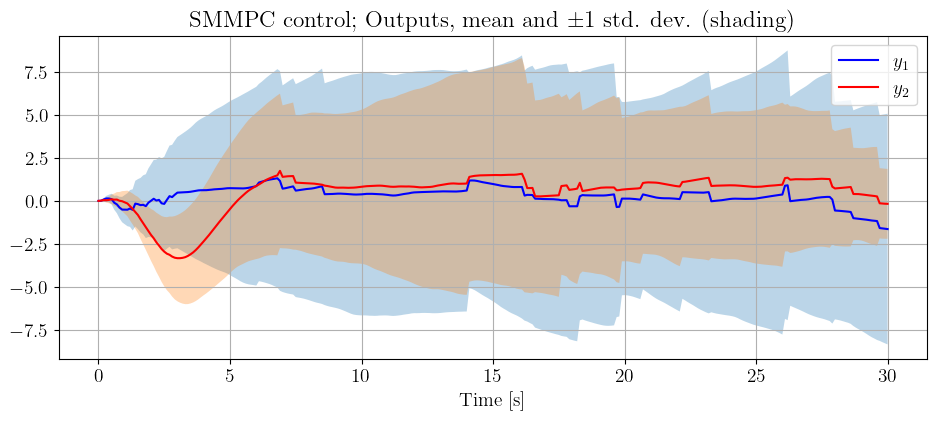

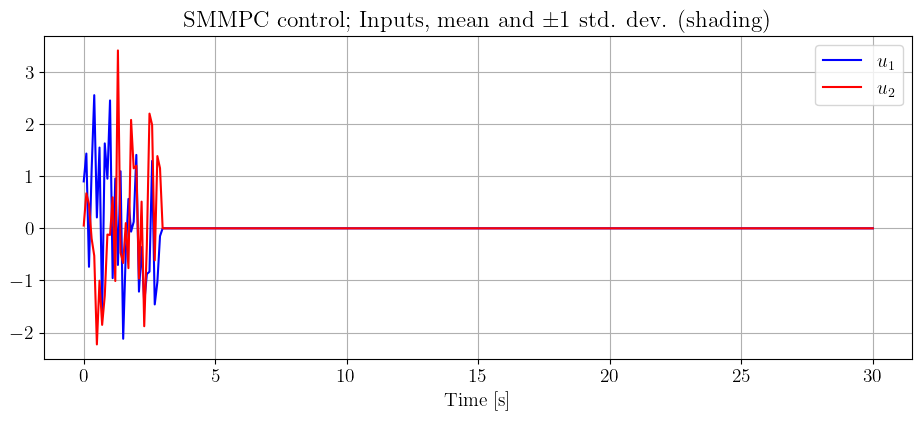

In [16]:
for mc_idx in range(nMC):
    # Extract noise for this run
    ymodnoise = vmod_mc[1 : K_DATA+1, :, mc_idx]    # MATLAB vmodMC(2:K+1,:,mcIdx)
    ysimnoise = vsim_mc[:, :, mc_idx]               # MATLAB vsimMC(:,:,mcIdx)
    wsim      = wsim_mc[:sim_len, :, mc_idx].T      # MATLAB wsimMC(1:simLen,:,mcIdx)'

    # SMM model data generation: add noise to nominal y-response
    # ynom_u has shape (NY, PRBS_LEN); drop first sample and transpose
    ymod = y_nom_u[:, 1 : K_DATA+1].T + ymodnoise   # MATLAB ynom_u(2:K+1,:) + ymodnoise

    # Calculate the SMM Hankel matrices
    # umod has shape (K_DATA, NU), use full 1:K rows
    Hup, Huf = make_smm(umod[:K_DATA, :], TP, TF, M)
    Hyp, Hyf = make_smm(ymod,        TP, TF, M)

        # 4) Full‐order SMMPC predictor setup
    SMMPC_nx = NY * TP  # full‐order state
    Eup, Eyp, Euf = make_SMM_pred(
        Hup, Huf, Hyp, Hyf,
        NU, NY, SMMPC_nx, params.SIGMA_V
    )

    # 5) Initialize controller history vectors
    up_SMMPC = np.zeros((NU * TP,))  # past inputs
    yp_SMMPC = np.zeros((NY * TP,))  # past outputs

    # 6) Initialize OSQP for SMMPC
    prob = osqp.OSQP()

    # 7) Build linear cost term for initial setup
    # yrefTf was defined earlier as vector of length NY*TF
    qy   = -2 * (Pyf @ yrefTf)                   # shape → (NY*TF,)
    qlin = np.hstack([np.zeros(NU * TF), qy])    # shape → (NU*TF + NY*TF,)

    # 8) Update equality and inequality constraints for SMMPC

    # Equality constraint: Aeq * z = 0, z = [uf; slack_y]
    # Aeq = [-Euf, I_{ny*Tf}]
    Aeq = sp.hstack([
        -sp.csc_matrix(Euf),
        sp.eye(NY * TF, format='csc')
    ], format='csc')

    # Inequality constraint: box on [uf; y] (no y slack here)
    Aineq = sp.eye((NU + NY) * TF, format='csc')

    # Stack constraints
    Acons = sp.vstack([Aeq, Aineq], format='csc')

    # Dynamics bounds from current past‐state histories
    lEq = Eup @ up_SMMPC + Eyp @ yp_SMMPC
    uEq = Eup @ up_SMMPC + Eyp @ yp_SMMPC

    # Combine with static inequality bounds
    lcons = np.hstack([lEq, lIneq])
    ucons = np.hstack([uEq, uIneq])

    # 9) Configure OSQP workspace for this run
    prob.setup(
        P=Pcost,
        q=qlin,
        A=Acons,
        l=lcons,
        u=ucons,
        verbose=False
    )

    # 10) Initialize storage for closed-loop variables
    u_SMMPC     = np.zeros((NU, sim_len))             # control inputs
    x_SMMPC     = np.zeros((Gnx, sim_len + 1))        # plant state (one extra step)
    y_SMMPC     = np.zeros((NY, sim_len))             # noise‐free outputs
    ymeas_SMMPC = np.zeros((NY, sim_len))             # noisy outputs

    for k in range(sim_len):
        # 1) Compute noise‐free output and measurement
        y_SMMPC[:, k]      = Gz.C @ x_SMMPC[:, k]
        ymeas_SMMPC[:, k]  = y_SMMPC[:, k] + ysimnoise[k, :]

        # 2) Update past‐output history yp_SMMPC (length NY*TP)
        # Remove the oldest block of size NY and append the newest measurement
        yp_SMMPC = np.concatenate([
            yp_SMMPC[NY:],          # drop first NY entries
            ymeas_SMMPC[:, k]       # add newest NY×1 vector
        ])

        if k >= params.K_INIT:
            # Update reference vector over future horizon
            # params.Y_REF has shape (sim_len+TF, NY)
            yrefTf = params.Y_REF[k : k + TF, :].T   # (NY, TF)
            yrefTf = yref_block.reshape((NY * TF,), order='F')

            # Dynamics bounds (same for lower and upper)
            lEq = Eup @ up_SMMPC + Eyp @ yp_SMMPC
            uEq = Eup @ up_SMMPC + Eyp @ yp_SMMPC

            # Combine with static inequality bounds
            lcons = np.hstack([lEq, lIneq])
            ucons = np.hstack([uEq, uIneq])

            # Linear cost term
            qy   = -2 * (Pyf @ yrefTf)                  # shape → (NY*TF,)
            qlin = np.hstack([np.zeros(NU * TF), qy])   # (NU*TF + NY*TF,)

                        # Solve the QP for this time step
            prob.update(l=lcons, u=ucons, q=qlin)
            res = prob.solve()
            if res.info.status != 'solved':
                warnings.warn("OSQP did not solve the problem!")
                break
            else:
                uopt = res.x[: NU * TF]       # optimal future inputs

            # Apply first control move
            u_SMMPC[:, k] = uopt[: NU]
        else:
            # Initialization using pre‐generated excitation
            u_SMMPC[:, k] = u_init[:, k]
        
                # 24) True plant evolution with process noise
        x_SMMPC[:, k+1] = (
            Gz.A @ x_SMMPC[:, k]
            + Gz.B @ np.concatenate([u_SMMPC[:, k], wsim[:, k]])
        )

        # 25) Update past‐input history up_SMMPC
        # Drop oldest block of size NU and append current input u_SMMPC[:,k]
        up_SMMPC = np.concatenate([
            up_SMMPC[NU:],          # remove first NU entries
            u_SMMPC[:, k]           # append new NU‐vector
        ])

        # --- Store trajectories for this Monte Carlo run ---
    uMC_SMMPC[:, :sim_len, mc_idx] = u_SMMPC
    yMC_SMMPC[:, :sim_len, mc_idx] = y_SMMPC

    # --- Compute performance metrics ---
    yerr = yMC_SMMPC[:, params.K_INIT:sim_len, mc_idx] \
         - params.Y_REF[params.K_INIT:sim_len, :].T
    ISE_SMMPC[mc_idx] = np.sum(yerr**2)
    IAE_SMMPC[mc_idx] = np.sum(np.abs(yerr))
    uclp = uMC_SMMPC[:, params.K_INIT:sim_len, mc_idx]
    IE_SMMPC[mc_idx] = np.sum(uclp**2)

    # --- Print summary ---
    t_end = params.T_CLP_GRID[sim_len-1]
    print(f"\nSMMPC run {mc_idx+1}/{n_mc}: simulation ended at t = {t_end} [sec] ({sim_len} time steps)")
    print(f"ISE = {ISE_SMMPC[mc_idx]:g}")
    print(f"IAE = {IAE_SMMPC[mc_idx]:g}")
    print(f"Input energy = {IE_SMMPC[mc_idx]:g}")

# Plot SMMPC Monte Carlo results

# Outputs
plt_resp(
    params.T_CLP_GRID,
    yMC_SMMPC,
    labels=[r'$y_1$', r'$y_2$'],
    styles=['b-', 'r-']
)
plt.title('SMMPC control; Outputs, mean and ±1 std. dev. (shading)')
plt.show()

# Inputs
plt_resp(
    params.T_CLP_GRID,
    uMC_SMMPC,
    labels=[r'$u_1$', r'$u_2$'],
    styles=['b-', 'r-']
)
plt.title('SMMPC control; Inputs, mean and ±1 std. dev. (shading)')
plt.show()